<a href="https://colab.research.google.com/github/legong-beep/MPM_204_Gong/blob/main/assignments/02_Assignment_Poisson_Regression_complete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MPM 204: Assignment 2

### Due 16th April 2026 9AM

#### For all questions, you must show your work. This will enable us to understand your thought process, give partial credit, and prevent crude cheating.
#### Please make sure that you are not simply copying each other's code, but rather striving to understand each other's work and learn from it.
#### Additionally, please provide the R code at the end of your solution and include R commands along with R outputs. This will help to describe your solutions more clearly.

## Section 0: Setup your project and analysis

1. Make sure you have installed all the relevant packages required for your analysis. You will mostly be using the glm function to run count models, in addition to other packages that allow you to read and manipulate data, as well as generate plots.
2. Set up your working directory appropriately.
3. Although you might not load all the necessary packages at the beginning, it is best practice to write code that loads all the required packages in one place. Therefore, it's recommended that you return to these first few lines to reload the packages if needed.

In [ ]:
## Start coding and answering

In [1]:
install.packages(c("ggplot2", "MASS", "sjPlot"))

library(ggplot2)
library(MASS)
library(sjPlot)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘rbibutils’, ‘Rdpack’, ‘reformulas’, ‘effectsize’, ‘bayestestR’, ‘datawizard’, ‘ggeffects’, ‘insight’, ‘parameters’, ‘performance’, ‘sjlabelled’, ‘sjmisc’, ‘sjstats’



Attaching package: ‘sjPlot’


The following object is masked from ‘package:ggplot2’:

    set_theme




## Section 1:

### Poisson and negative binomial distrbutions

* California is known to have five new cases of bovine respiratory diseases every day.
* We have decided to collect daily data for two years, which is equivalent to 730 days.
* Assuming that the incidence rate of new cases is not affected by the number of cases observed in the previous days,
#### Q1: Generate a **vector** of 730 days showing simulated data that will closely match your observed case data with an average rate of five cases per day.  
1a. What other parameter is needed to generate the distribution using R commands? Assign the generated vector an object name and convert it into a dataframe.  
1b. What value did you use, and how can you interpret it in terms of what it tells us about the events?
1c. Use GGplot to create a histogram of your distribution.  
1d. Provide appropriate x and y-axis labels in the plot that are descriptive enough for readers to understand the data.  
  
Points: 5.  

ANSWERS:

1a. number of observations, n.

1b. lambda:5; this means 5 cases per day on average

1c. #code for ggplot

1d. #added x-axis and y-axis labels

In [5]:
BRD_cases_sim <- rpois(n = 730, lambda = 5) ## code to generate data vector following Poisson distribtuion
#added 5 observations an 730 days to simulate

In [9]:
BRD_cases_DF <- as.data.frame(x=BRD_cases_sim) ## USe this code to convert it to a datagrame
 xlab("Number of new BRD cases per day") +
  ylab("Number of days")

NULL

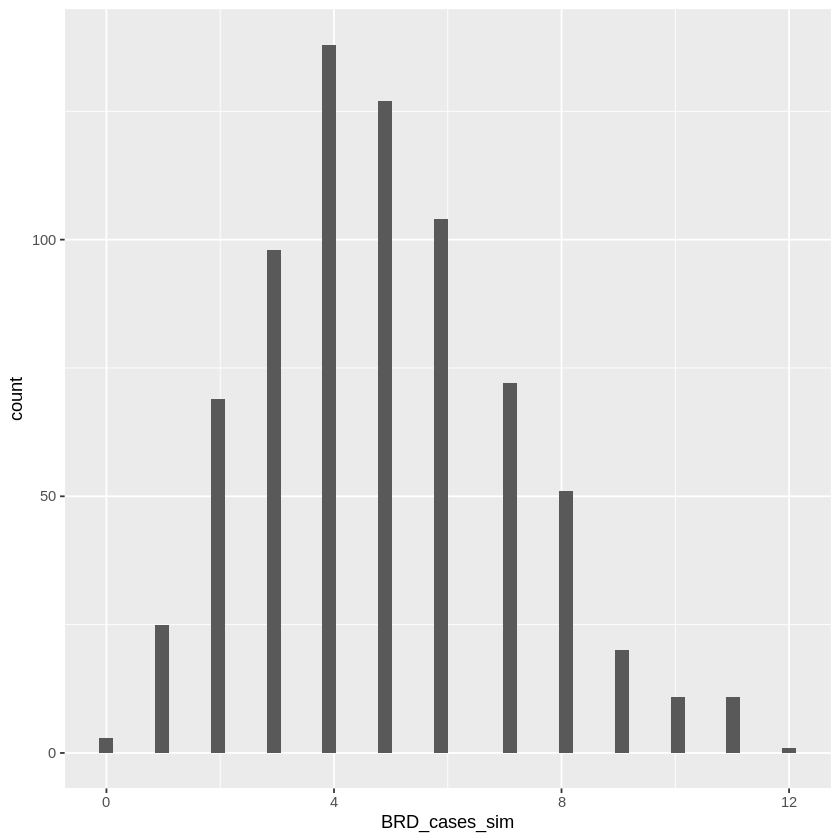

In [11]:
ggplot(, aes(x= BRD_cases_sim)) +
  geom_histogram(bins = 50)

#### Q2: How can you re-prove that this is Poisson distribution?
Which two statistical properties of this data will you use to show that?   
Point: 2   

ANSWER:

lambda and variance are about the same. So they both would be 5.

In [12]:
#Q2 calculating both mean and variance
mean(BRD_cases_sim)
var(BRD_cases_sim)

[1] 4.935616

[1] 4.820266

#### Q3: Understanding Negative Binomial Distribution
Q3a: If the mean of a negative binomial distribution is 10 and the theta is 5, what will be the variance of the distribution? Perform these calculations by hand, i.e., without using R.    
  
Points: 3.  

#### Q4:Now check your answer by generating a random dataframe with values from Negative Binomial Distribution using the R code
Q4a: According to the R documentation, what information is provided for all the arguments in the code line `rnegbin`?  
  
Q4b: Which library does the function `rnegbin` belong to?  
  
Q4c: Calculate the mean and variance of the generated data in R. Is it similar to your answer for Q3?  
  
Points: 3.  

ANSWERS:

3a. negative binomial: variance=mean+(mean^2/theta)
variance=10+(100/5)= 30
variance=30

4a. n= if a scalar, the number of sample values required; mu = The vector of means, theta= Vector of values of the ‘theta’ parameter

4b. package:MASS

4c. mean = 9.994

variance = 29.6255895895896

Yes, they are similar to the mean and variance in Q3.


In [13]:
#Q4a
?rnegbin

[1] 9.994

[1] 29.62559

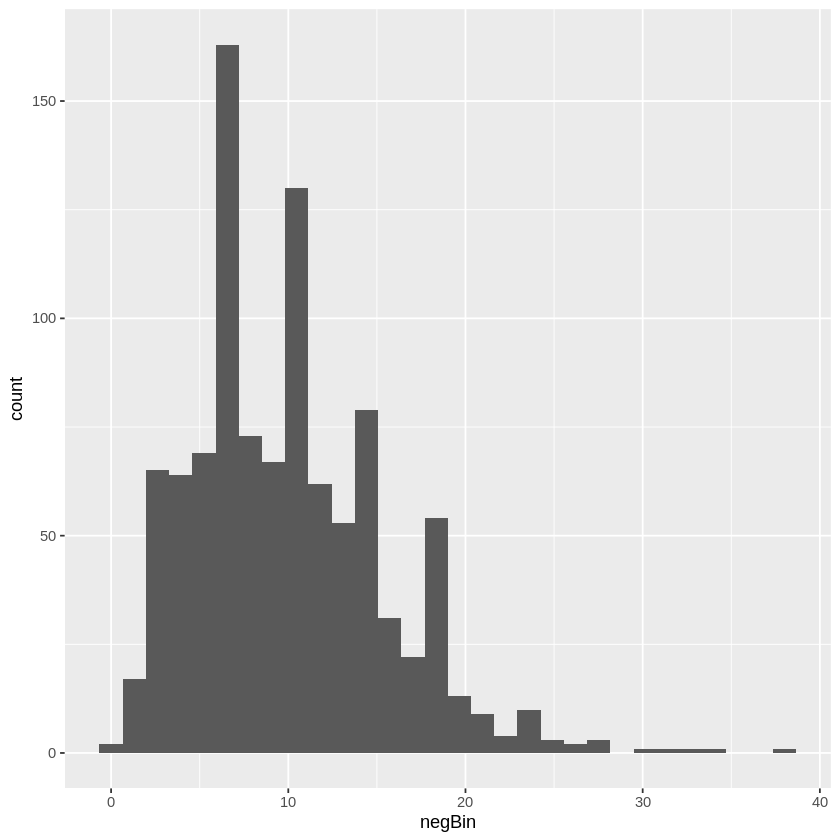

In [15]:
#Q4c
chose 1000 bc large enough number to get a reliable mean and variance
negBin <- rnegbin(n = 1000, mu = 10, theta = 5)
negBinDF <- as.data.frame(x=negBin)
ggplot(negBinDF, aes(x=negBin)) +
  geom_histogram(bins = 30)

mean(negBin)
var(negBin)

## Section 2: TB incidence in cattle, deer, bison herds

Read/import data from **tb_real.csv** file in R

In [17]:
#read the csv from appropriate folder
  TB_df <- read.csv("/content/tb_real.csv")
head(TB_df)

,FarmID,TB,Type,Sex,Age,PAR
,<int>,<int>,<chr>,<chr>,<chr>,<int>
1,4002,1,Beef,Female,0-12mo,525
2,4002,2,Beef,Female,12-24mo,3675
3,4002,5,Beef,Female,24+mo,5775
4,4002,3,Beef,Male,12-24mo,2625
5,4002,1,Beef,Male,24+mo,525
6,4003,2,Beef,Female,24+mo,7824


In [18]:
head(TB_df)

,FarmID,TB,Type,Sex,Age,PAR
,<int>,<int>,<chr>,<chr>,<chr>,<int>
1,4002,1,Beef,Female,0-12mo,525
2,4002,2,Beef,Female,12-24mo,3675
3,4002,5,Beef,Female,24+mo,5775
4,4002,3,Beef,Male,12-24mo,2625
5,4002,1,Beef,Male,24+mo,525
6,4003,2,Beef,Female,24+mo,7824


The number of new tuberculosis (TB) infections in dairy and beef cattle, cervid (deer and elk), and bison herds in TB outbreaks in Canada between 1985 and 1994 were recorded. Infections were diagnosed by the reactor, a significant response to the tuberculin skin test. Several important characteristics of the outbreaks were also recorded: type of herd, sex of animals in the herd, age group of animals in the herd, and population attributable risk (PAR) in herd at the time of infection. The data were recorded as follows:

#### Variable name Level indicator Description
* FarmID:  Unique farm ID at the time of the outbreak
* TB: Number of TB reactors per herd
* Type: Type of infected animals in the herd
* Sex: Gender of infected animals in the herd
* Age: Age group of infected animals in the herd
* PAR: Population at risk in herd at the time of infection

#### Q5: Explore the association between TB incidence and the Population at risk  

* Visualize the association via a scatter plot
Points: 5

Warning message in scale_y_continuous(trans = "log"):
“log-2.718282 transformation introduced infinite values.”


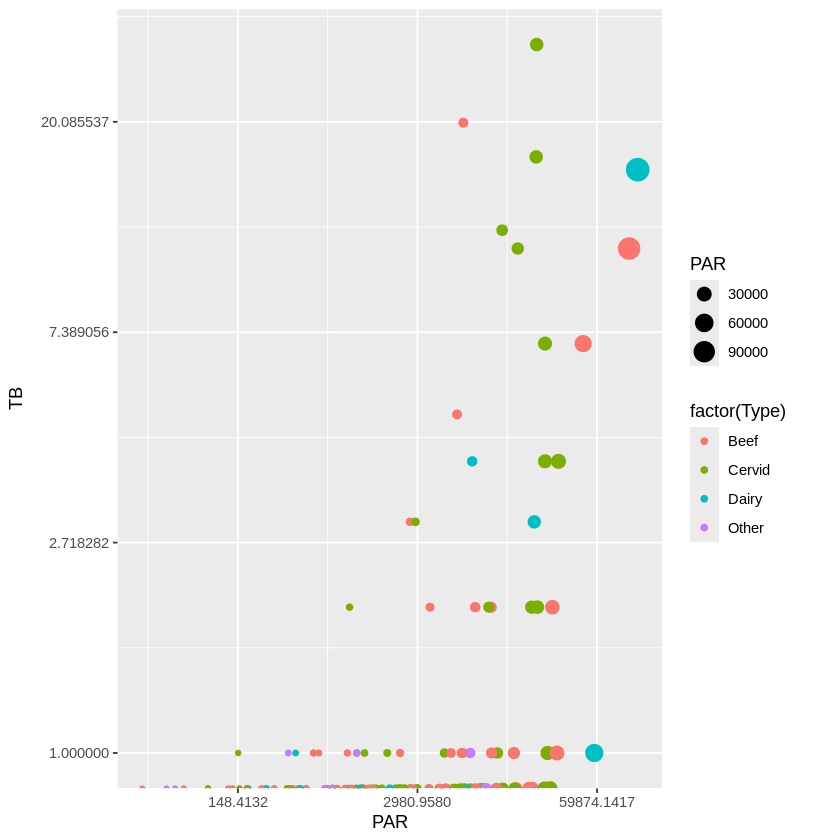

In [26]:
ggplot(TB_df, aes(x = PAR, y = TB)) +
  geom_point(aes(color = factor(Type), size = PAR)) +
  scale_x_continuous(trans='log') +
  scale_y_continuous(trans='log')
  #scatter plot of TB incidence vs population at risk (PAR); type
  #and change scale of axis to log

Warning message in scale_y_continuous(trans = "log"):
“log-2.718282 transformation introduced infinite values.”


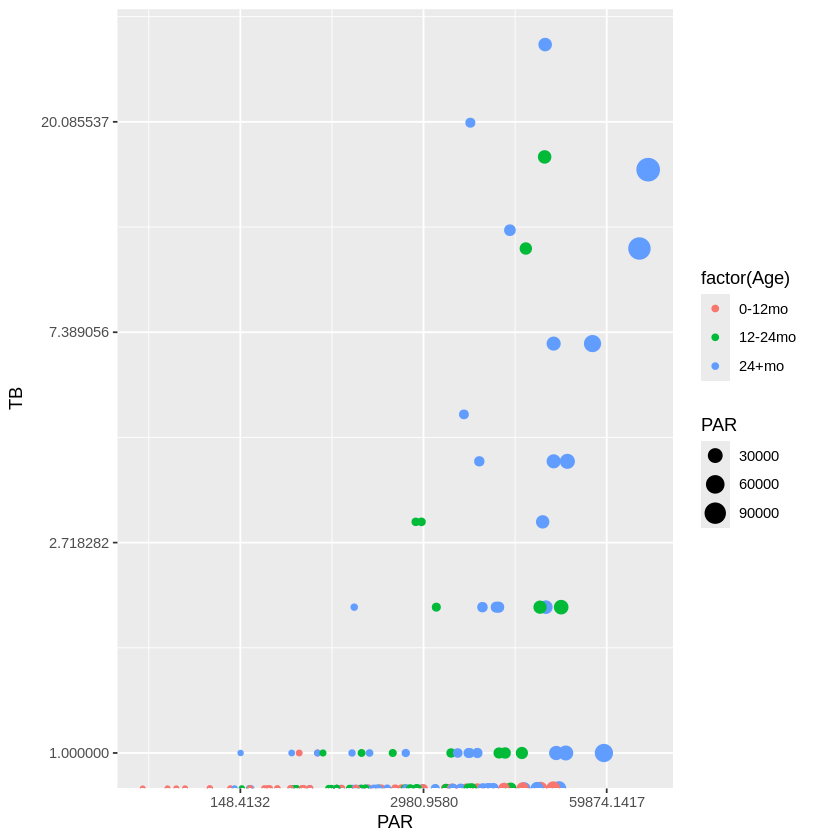

In [27]:
#colored by age
ggplot(TB_df, aes(x = PAR, y = TB)) +
  geom_point(aes(color = factor(Age), size = PAR)) +
  scale_x_continuous(trans='log') +
  scale_y_continuous(trans='log')

#### Plotting outcome with two covariates

1. Lets color points by the type of herds and size of dots and also by the population at risk
2. Generate a plot by the by assigning age of the herd to the color property of points and size of dots by the population at risk

In [ ]:
### use these arruments to choose colors and size of dots
geom_point(aes(color = factor(Type), size = PAR))+


In [ ]:
geom_point(aes(color = factor(Age), size = PAR))+


#### Q6: Based on the data and graphs provided, do you think that age and population have an effect on the incidence of TB? While it may be difficult to draw definitive conclusions from the data, exploring it can help generate possible hypotheses.  
  
Points: 2   

ANSWER:

With blue dots (older animals) apearing hihger on the TB axis, compared to other dots, it may suggest older animals have more TB cases and PAR get larger going to the right. This could suggest larger populations have more TB cases.



#### Q6a: Let's add a linear regression line to the plot in order to explore any possible associations in more detail.
This can be accomplished using the `GGplot` function `stat_smooth`. Check the documentation for `stat_smooth` to use linear regression to draw the line, and ensure that standard errors are shown.  

Q6b: After examining the plot with the regression line, do you believe that there is an association between population at risk (PAR) and TB incidence?  
  
Points: 5

ANSWER:

Q6b. Yes. The regression line moves up and to the right, showing a positive association between PAR and TB cases.

Warning message in scale_y_continuous(trans = "log"):
“log-2.718282 transformation introduced infinite values.”
Warning message in scale_y_continuous(trans = "log"):
“log-2.718282 transformation introduced infinite values.”
`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 87 rows containing non-finite outside the scale range
(`stat_smooth()`).”


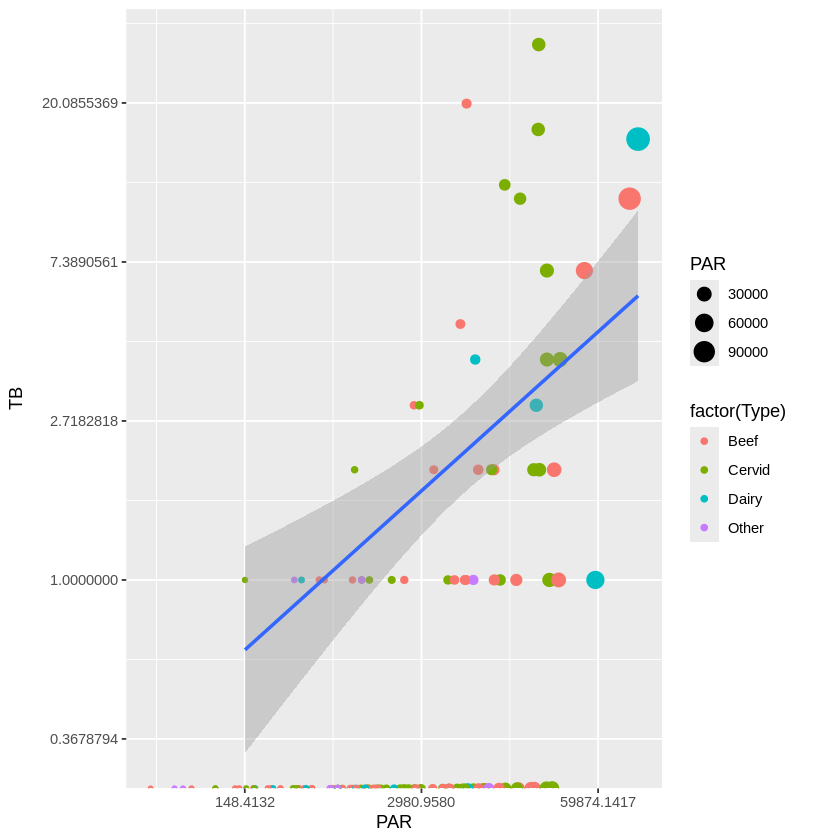

In [28]:
#add regression line with stat_smooth
ggplot(TB_df, aes(x = PAR, y = TB)) +
  geom_point(aes(color = factor(Type), size = PAR)) +
  stat_smooth(method = "lm", se = TRUE) +
  scale_x_continuous(trans='log') +
  scale_y_continuous(trans='log')

#### Q 7: Plot histograms for all numeric variables  
Points: 2

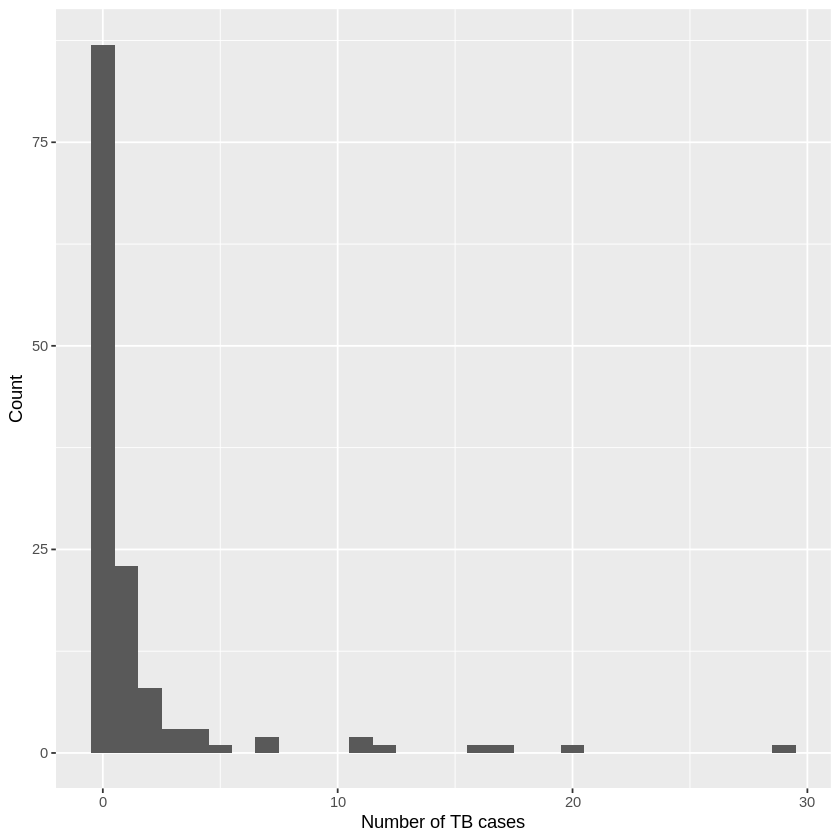

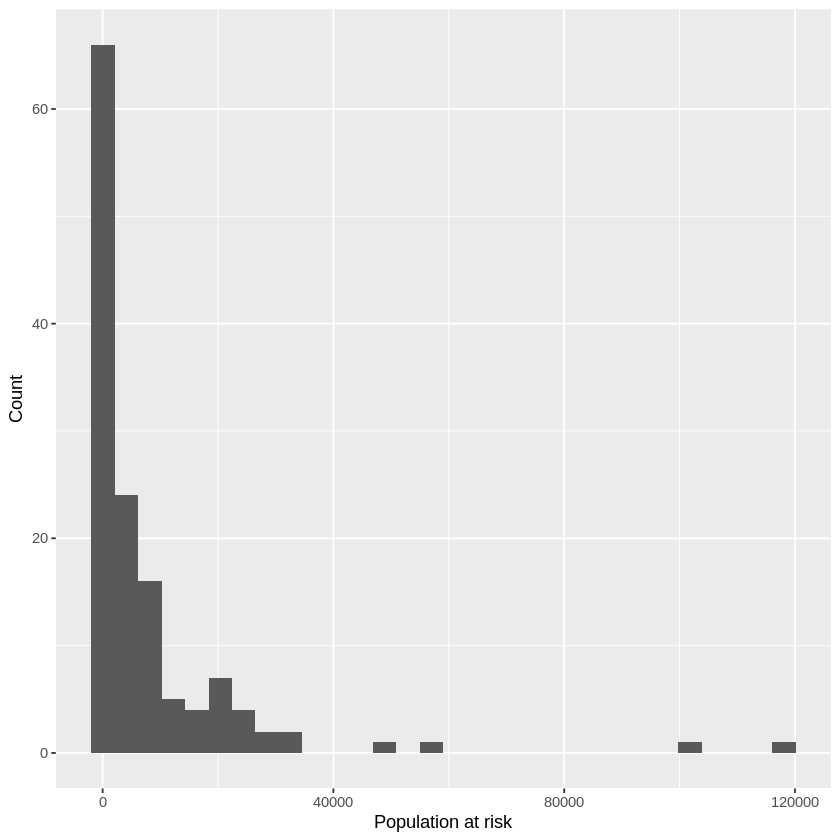

In [29]:
ggplot(TB_df, aes(x = TB)) +
  geom_histogram(bins = 30) +
  xlab("Number of TB cases") +
  ylab("Count")

ggplot(TB_df, aes(x = PAR)) +
  geom_histogram(bins = 30) +
  xlab("Population at risk") +
  ylab("Count")

#### Q8: What statistical properties of the outcome variable (TB) will you check first before proceeding with regression modeling?
Calculate them using `R`  
Points:3  

ANSWERS:

Checking that the mean and variance of the TB outcome variable are approximately equal would mean poisson distribution is appropriate. If variance is larger than the mean, negative binomial distribution would be more appropriate.

In [30]:
#checking mean and variance
mean(TB_df$TB)
var(TB_df$TB)

[1] 1.455224

[1] 16.09948

#### Q9: Give your opinion on which distribution family you think will be more appropriate for this data, and why?
Points: 3

ANSWER:

Given that the variance is much larger than the mean (overdispersion), negative binomial distribution is appropriate for this data because it accounts for overdispersion through theta parameter.

## Section 3: TB Incidence

#### Q10:

* a) Define the incidence rate of TB infections per 100,000 animal years as the number of TB reactors divided by the number of animals at risk and an appropriate constant.

* b) Keep in mind that this study was conducted over a period of 10 years.

* c) Write down the equation for the Poisson regression model (notation only) that relates the TB rate (cases per 100,000 animal years at risk) to animal type, sex, and age.  
  
Points: 5  

ANSWERS:

a) Incidence rate = (TB reactors/number of animals at risk) x 100,000.

c) log(IR)= β₀ + β₁(Type)+β₂(Sex)+β₃(Age)

In [31]:
#code implementing Q10a and Q10b
TB_df$IR <- (TB_df$TB / (TB_df$PAR * 10)) * 100000

## Section 4: Generalized linear model with Poisson distribution
Regardless of your previous answer, we will proceed with the Poisson distribution for the purpose of this assignment.

#### Q 11:  Fit a Poisson regression model to the data of TB infections that is corrected for the population-attributable risk. After fitting the model, please provide a summary of the fit.

In [32]:
#fitting poisson regression model predicting TB cases from type, sex, and age
#adjusting for population size
model1 <- glm(TB ~ Type + Sex + Age + offset(log(PAR/10000)),
              data = TB_df,
              family = poisson)
summary(model1)


Call:
glm(formula = TB ~ Type + Sex + Age + offset(log(PAR/10000)), 
    family = poisson, data = TB_df)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)    
(Intercept) -2.037306   0.717552  -2.839 0.004522 ** 
TypeCervid   0.624027   0.165801   3.764 0.000167 ***
TypeDairy   -0.442215   0.236412  -1.871 0.061410 .  
TypeOther   -0.003831   0.593519  -0.006 0.994850    
SexMale     -0.361881   0.195397  -1.852 0.064022 .  
Age12-24mo   2.673407   0.721738   3.704 0.000212 ***
Age24+mo     2.601178   0.713634   3.645 0.000267 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for poisson family taken to be 1)

    Null deviance: 409.03  on 133  degrees of freedom
Residual deviance: 348.35  on 127  degrees of freedom
AIC: 491.32

Number of Fisher Scoring iterations: 8


In [34]:
#for each predictor, how many times higher is
#the TB rate compared to the reference group
exp(coef(model1))

(Intercept)  TypeCervid   TypeDairy   TypeOther     SexMale  Age12-24mo 
  0.1303795   1.8664289   0.6426115   0.9961764   0.6963654  14.4892542 
   Age24+mo 
 13.4796111

#### Q12 Interpret the estimated intercept and slope of the sex predictor for the model above.

ANSWER:

sex/male: 0.69636539. This means males have 0.696 times the TB rate of females, so males have a lower TB rate than females, about 30% lower (1-0.696)

The intercept represents TB incidence when all predictors are at their reference category.

#### Q13: Fit a model with interactions between Type, Age, and Sex (with a population offset). Assume that this is the saturated model. Perform an overall goodness-of-fit test via LRT at a 5% significance level to determine if the previous Poisson model (`model1`) fits the data well.

ANSWER:

p-value 0.0596 is close to the cutoff, so it's not a very strong significance. The poisson model fits.

In [35]:
sat_model <- glm(TB ~ Type*Sex*Age + offset(log(PAR/10000)),
                 data = TB_df,
                 family = poisson)

anova(model1, sat_model, test = "LRT")

,Resid. Df,Resid. Dev,Df,Deviance,Pr(>Chi)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,127,348.3521,NA,NA,NA
2,110,321.4611,17,26.89106,0.059685


## Section 5: Predictions

### In this section, we will see the behavior of predicted values from our model
#### Q 15
1. We will use function `predict` and
2. plot the association between observed and predicted data

Points: 3

In [36]:
predict(object = model1, newdata = TB_df, type = "response")

1            2            3            4            5            6 
6.844926e-03 6.942451e-01 1.014936e+00 3.453202e-01 6.425151e-02 1.375041e+00 
           7            8            9           10           11           12 
5.654133e-02 1.623898e-01 1.130827e-01 1.532861e+00 4.919991e-02 3.024805e-03 
          13           14           15           16           17           18 
1.677523e-01 1.793142e+00 4.212740e-03 7.822773e-04 3.249256e-02 5.138829e-01 
          19           20           21           22           23           24 
2.723754e-04 2.105002e-02 1.642782e-03 2.103686e-01 8.392331e-01 1.392021e-02 
          25           26           27           28           29           30 
3.259174e-03 7.922296e-01 6.457272e+00 5.319485e-03 1.115639e+00 2.469537e-03 
          31           32           33           34           35           36 
7.551002e-02 1.294821e-01 5.051825e-02 7.739296e-01 2.809806e+00 2.065674e-02 
          37           38           39           40           41           42 
6.484441e-01 5.148603e-01 1.015452e+00 3.215893e+00 1.525108e-03 3.535628e-01 
          43           44           45           46           47           48 
2.811859e-01 1.460065e-01 7.166547e+00 1.220086e-01 2.188270e-01 1.570101e-02 
          49           50           51           52           53           54 
7.997561e-01 2.368961e+00 2.450442e-03 1.041026e-01 4.379137e+00 8.588179e+00 
          55           56           57           58           59           60 
5.043024e-02 2.784307e+00 3.147637e-01 2.542143e-01 3.732052e-02 3.403468e-02 
          61           62           63           64           65           66 
6.022565e-02 4.193906e-02 2.730574e+00 9.471640e-02 3.650162e-02 8.462101e-01 
          67           68           69           70           71           72 
1.556120e+00 1.149079e+00 1.016960e-02 1.385586e+00 6.537010e-03 8.682336e-02 
          73           74           75           76           77           78 
2.920130e-02 1.269315e-01 8.237199e+00 1.220086e-02 5.049011e+00 2.538630e-01 
          79           80           81           82           83           84 
1.797541e+00 3.755236e-01 3.807945e-01 1.525108e-03 5.662458e-02 8.200698e-03 
          85           86           87           88           89           90 
6.346576e-01 1.031290e+01 2.948542e-03 2.651721e-01 6.261011e+00 5.844646e-04 
          91           92           93           94           95           96 
2.032430e-01 1.638698e+00 4.703122e-04 9.435424e-02 8.777943e-01 1.400253e-03 
          97           98           99          100          101          102 
2.642924e-01 8.339174e+00 1.011693e-01 2.726712e-01 6.293421e-02 8.160922e-01 
         103          104          105          106          107          108 
5.383644e+00 4.289913e-02 3.551865e-01 1.610571e-01 1.940675e+00 3.364844e+00 
         109          110          111          112          113          114 
1.742746e-01 2.063265e-01 1.094198e+00 6.347966e-01 9.179243e-01 6.068516e-01 
         115          116          117          118          119          120 
7.082073e+00 2.559809e-01 1.527932e+00 7.637046e+00 4.024458e+00 3.909079e+00 
         121          122          123          124          125          126 
5.734273e+00 8.269101e-02 1.393625e-01 1.333602e+01 9.704721e-02 7.675777e-02 
         127          128          129          130          131          132 
1.290757e-02 5.365051e+00 1.798362e+01 1.997420e-03 1.963260e+00 5.903796e-01 
         133          134 
1.127941e+00 1.652182e-02

In [37]:
TB_df['TB_predict'] =  predict(object = model1, newdata = TB_df, type = "response")

In [38]:
head(TB_df)

,FarmID,TB,Type,Sex,Age,PAR,IR,TB_predict
,<int>,<int>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>
1,4002,1,Beef,Female,0-12mo,525,19.047619,0.006844926
2,4002,2,Beef,Female,12-24mo,3675,5.442177,0.694245122
3,4002,5,Beef,Female,24+mo,5775,8.658009,1.014936361
4,4002,3,Beef,Male,12-24mo,2625,11.428571,0.345320201
5,4002,1,Beef,Male,24+mo,525,19.047619,0.064251506
6,4003,2,Beef,Female,24+mo,7824,2.556237,1.375041054


#### Q16: Plot histrogram of predicted values to compare with observed values

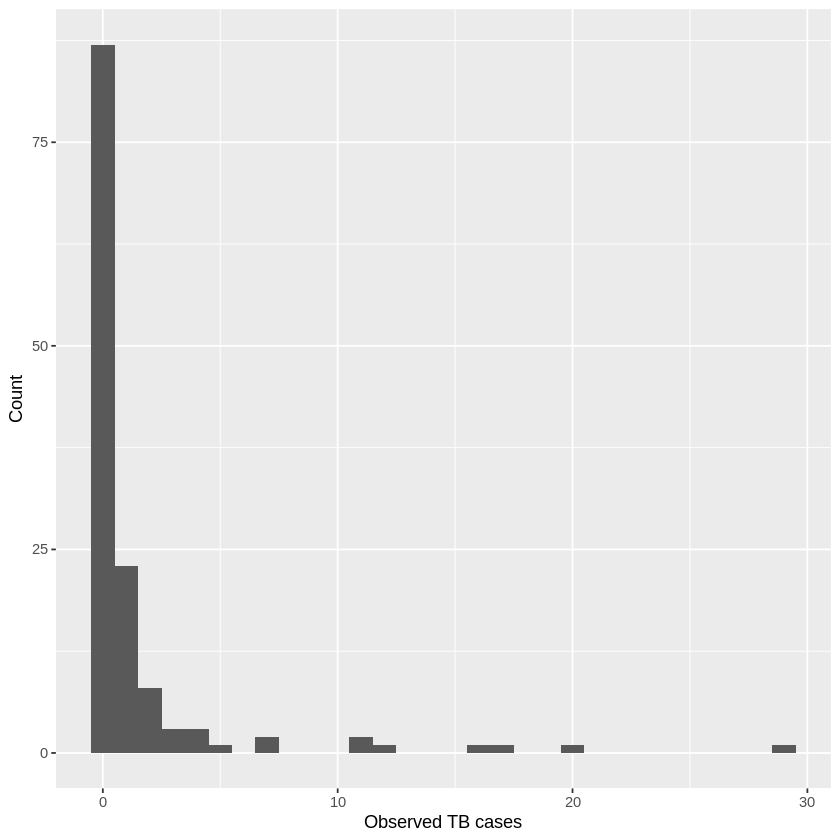

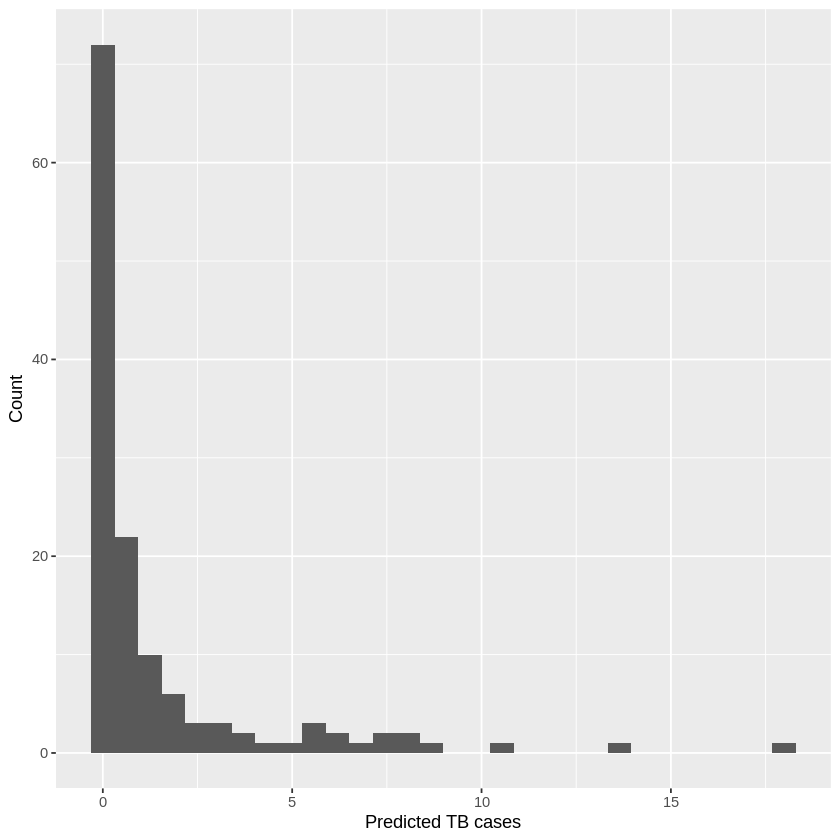

In [39]:
ggplot(TB_df, aes(x = TB)) +
  geom_histogram(bins = 30) +
  xlab("Observed TB cases") +
  ylab("Count")

ggplot(TB_df, aes(x = TB_predict)) +
  geom_histogram(bins = 30) +
  xlab("Predicted TB cases") +
  ylab("Count")

In [ ]:
#observed reaches 30 and predicted only reaches 18
#suggests model is underestimating extreme high values, evidence of overdispersion
#poisson doesn't capture those high counts

#### Q17: plot a scatterplot with linear regression line PREDICTED and Observed TB cases

`geom_smooth()` using formula = 'y ~ x'


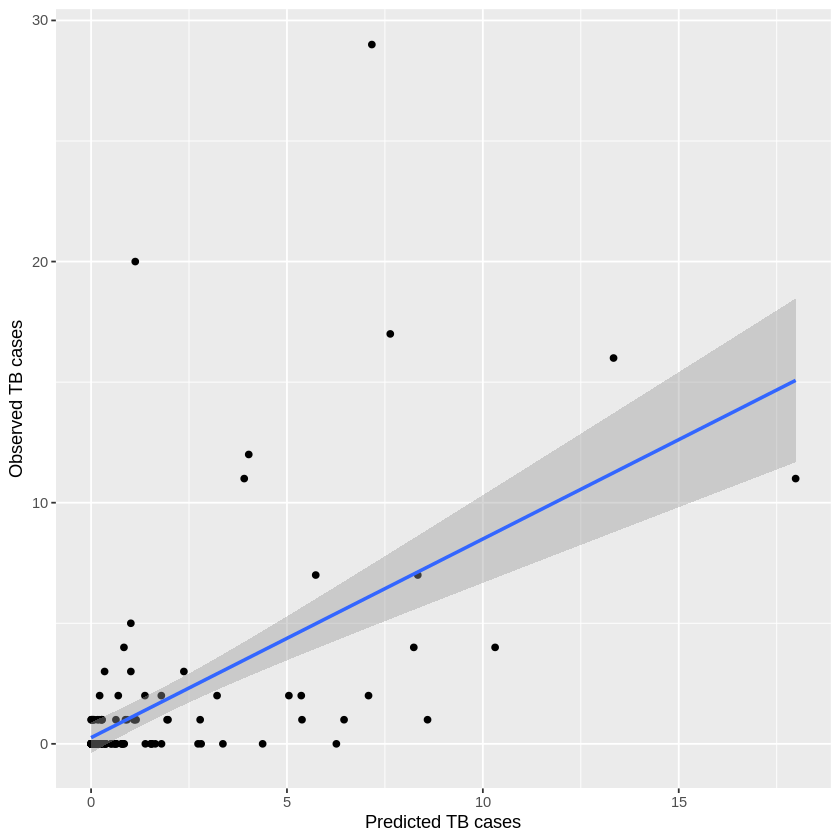

In [40]:
ggplot(TB_df, aes(x = TB_predict, y = TB)) +
  geom_point() +
  stat_smooth(method = "lm", se = TRUE) +
  xlab("Predicted TB cases") +
  ylab("Observed TB cases")

In [ ]:
#points are spread out around the line, and several observed values higher than the predicted
#suggests model doesnt capture variation that well

#### Q18: Estimate the dispersion parameter for the given model. Is there any apparent evidence of overdispersion? Please explain.
Also, what is the theta value for the model?

ANSWER:

Dispersion parameter is 2.74, which is higher than 1. This is evidence of overdispersion.

Null

In [41]:
#calculating dispersion parameter
summary(model1)$deviance / summary(model1)$df.residual

[1] 2.74293

In [42]:
summary(model1)$theta

NULL

## Section 6: Negative binomial regression

#### Q19

Use negative binomial regression to fit a model similar to the one in section 4.
* assuming that the TB counts are distributed as a negative binomial distribution instead of Poisson.
* You can use the glm command in R and set `family = negative.binomial(theta=0.5746, link=log)`,
* or you can use the command `glm.nb` from the MASS package.

`model = glm.nb(TB ~ Type + Sex + Age + offset( ... ), data = data)`  

* Report the summary of the fitted model and perform an overall goodness of fit test via LRT at a 5% significance level to see if the negative binomial model of TB incidence rate fits the data well.

Points: 10

In [45]:
negmodel1 <- glm.nb(TB ~ Type + Sex + Age + offset(log(PAR/10000)),
                    data = TB_df,
                    init.theta = 0.5746,
                    link = log)
summary(negmodel1)


Call:
glm.nb(formula = TB ~ Type + Sex + Age + offset(log(PAR/10000)), 
    data = TB_df, init.theta = 0.5745878389, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.36645    0.75997  -1.798 0.072172 .  
TypeCervid   0.06111    0.38344   0.159 0.873375    
TypeDairy   -0.60461    0.62282  -0.971 0.331663    
TypeOther    0.19542    0.82798   0.236 0.813411    
SexMale     -0.05748    0.38337  -0.150 0.880821    
Age12-24mo   2.25299    0.77912   2.892 0.003831 ** 
Age24+mo     2.48091    0.75279   3.296 0.000982 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(0.5746) family taken to be 1)

    Null deviance: 111.33  on 133  degrees of freedom
Residual deviance:  99.36  on 127  degrees of freedom
AIC: 331.47

Number of Fisher Scoring iterations: 1


              Theta:  0.575 
          Std. Err.:  0.143 

 2 x log-likelihood:  -315.472 

In [ ]:
#AIC dropped to 331.47

In [47]:
model_sat_nb <- glm.nb(TB ~ Type*Sex*Age + offset(log(PAR/10000)),
                       data = TB_df)
anova(negmodel1, model_sat_nb, test = "LRT")

Warning message in anova.negbin(negmodel1, model_sat_nb, test = "LRT"):
“only Chi-squared LR tests are implemented”


Model,theta,Resid. df,2 x log-lik.,Test,df,LR stat.,Pr(Chi)
<chr>,<dbl>,<int>,<dbl>,<chr>,<int>,<dbl>,<dbl>
Type + Sex + Age + offset(log(PAR/10000)),0.5745878,127,-315.4718,,NA,NA,NA
Type * Sex * Age + offset(log(PAR/10000)),0.6166959,110,-297.0580,1 vs 2,17,18.41376,0.3631994


In [ ]:
#p-value is greatwe than 0.05. We fail to reject the null and conclude the additive model fits well.

#### Q20: Observe the behavior of the model if we do not specifically mention the theta value in the model. Report the findings.
Point: 1

In [48]:
negmodel2 <- glm.nb(TB ~ Type + Sex + Age + offset(log(PAR/10000)),
                    data = TB_df)
summary(negmodel2)


Call:
glm.nb(formula = TB ~ Type + Sex + Age + offset(log(PAR/10000)), 
    data = TB_df, init.theta = 0.574590251, link = log)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.36649    0.76000  -1.798 0.072176 .  
TypeCervid   0.06111    0.38345   0.159 0.873376    
TypeDairy   -0.60461    0.62282  -0.971 0.331664    
TypeOther    0.19542    0.82798   0.236 0.813414    
SexMale     -0.05748    0.38337  -0.150 0.880821    
Age12-24mo   2.25303    0.77915   2.892 0.003832 ** 
Age24+mo     2.48095    0.75283   3.296 0.000982 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for Negative Binomial(0.5746) family taken to be 1)

    Null deviance: 111.33  on 133  degrees of freedom
Residual deviance:  99.36  on 127  degrees of freedom
AIC: 331.47

Number of Fisher Scoring iterations: 1


              Theta:  0.575 
          Std. Err.:  0.143 

 2 x log-likelihood:  -315.472 

In [ ]:
#results are essentially the same to negmodel with theta=0.575, compared to 0.5746)
#AIC is 331.47,exactly the same
#ALl coefficents are also the same

In [ ]:
model_nb = glm.nb()
model_sat_nb=glm.nb()

In [ ]:
anova()

Because the p-value is smaller than the significant level of 0.05, we fail to reject the null hypothesis. We conclude that the additive model fits the data better.  

#### Q21: Create a table showing the regression coefficients (betas) and their corresponding standard errors for the negative binomial model. Also, include the transformed slopes along with their estimated 95% confidence intervals (leave the intercept blank). Then, interpret each regression coefficient by describing the effect of animal type, sex, and age on the TB incidence rate. For this interpretation, assume that the risk populations are similar across the compared groups.

* use two methods to get your IRRs
1. exponentiate all coefficients
2. use `tab_model` function

Points: 10

In [50]:
#method 1
exp(coef(negmodel2))
exp(confint(negmodel2))

(Intercept)  TypeCervid   TypeDairy   TypeOther     SexMale  Age12-24mo 
  0.2550010   1.0630162   0.5462867   1.2158243   0.9441425   9.5165310 
   Age24+mo 
 11.9525882

Waiting for profiling to be done...



,2.5 %,97.5 %
(Intercept),0.03355538,1.232183
TypeCervid,0.49337050,2.331410
TypeDairy,0.15330650,2.197991
TypeOther,0.16473184,7.694297
SexMale,0.42404252,2.077953
Age12-24mo,1.91218439,73.472072
Age24+mo,2.51825117,89.745262


In [54]:
#method 2
tab_model(negmodel2, show.reflvl = TRUE, show.intercept = FALSE)

Cervid animals have 1.063 times the TB rate of beef animals (95% CI: 0.493–2.331).

Dairy animals have 0.546 times the TB rateof beef animals (95% CI: 0.153–2.198).

Other type animals have 1.216 times the TB rate of beef animlas (95% CI: 0.165–7.694).

Males have 0.944 times the TB rate of females (95% CI: 0.424–2.078).

Animals aged 12-24 months have 9.517 times the TB rate of 0-12 month animals (95% CI: 1.912–73.472).

Animals 24+ months have 11.953 times the TB rate of 0-12 month animals (95% CI: 2.518–89.745).

#### Q22: BONUS Q: Can you use a function from package `Sjplot` to generate a `forest` plot for your model results?
Points: 2